# Synthesis — Fund × Segment × RM
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

This notebook cross-cuts the three sections into one picture of where AUM is made and lost, then converts every finding into a **specific, owner-assigned recommendation tied to a number**. It consumes the metric tables emitted by `section1/2/3` (no recomputation of raw business rules).

> **Caveat carried forward:** "performance" throughout = flow / retention / engagement, **not** investment return — there is no NAV series in the data.

In [1]:
import sys; sys.path.insert(0,'.')
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import _common as C
defs=C.load_defs(); C.set_style(); SEC='synthesis'
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS
A=C.ANALYSIS
m1=json.load(open(A/'section1/_metrics.json'))
m2=json.load(open(A/'section2/_metrics.json'))
m3=json.load(open(A/'section3/_metrics.json'))
acc=C.load_accounts()
seg=pd.read_csv(A/'section2/tables/customer_segments.csv')
seg['mobile_no']=seg['mobile_no'].astype(str); acc['mobile_no']=acc['mobile_no'].astype(str)
print('loaded section metrics + segment table', seg.shape)

loaded section metrics + segment table (8535, 7)


## A. Fund × Segment — who holds what, and where the cross-sell sits
Map customer segments (Section 2) onto their dominant fund. This tells the fund manager which customer type defends each fund and which segment to target for growth.

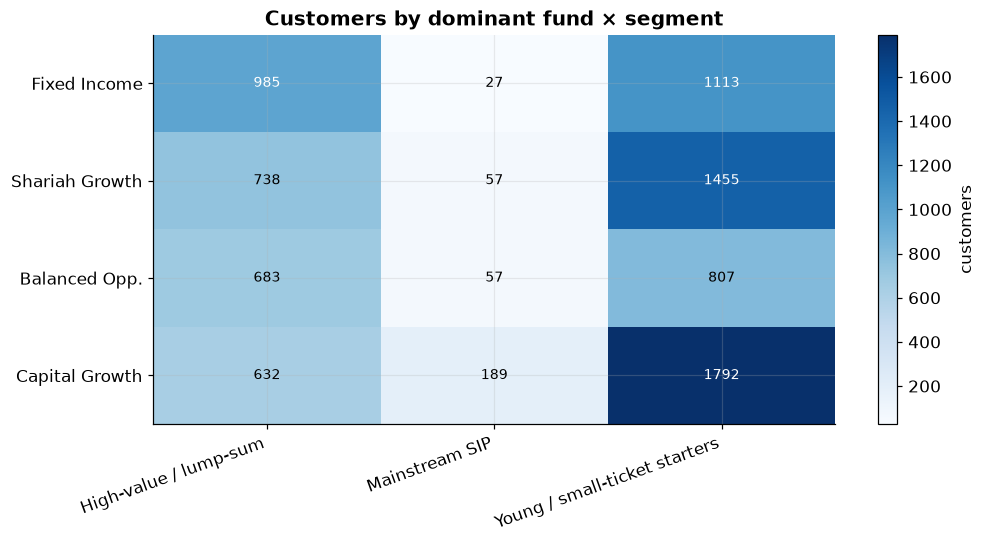

segment,High-value / lump-sum,Mainstream SIP,Young / small-ticket starters
dominant_fund,,,
Apex Fixed Income Fund,985,27,1113
Apex Shariah Growth Fund,738,57,1455
Apex Balanced Opportunity Fund,683,57,807
Apex Capital Growth Fund,632,189,1792


In [2]:
fs=pd.crosstab(seg.dominant_fund, seg.segment)
fs=fs.reindex(FUNDS)
C.save_table(fs,SEC,'fund_x_segment_counts')
fig,ax=plt.subplots(figsize=(10,4.6))
im=ax.imshow(fs.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(fs.columns))); ax.set_xticklabels(fs.columns, rotation=20, ha='right')
ax.set_yticks(range(len(fs.index))); ax.set_yticklabels([SHORT[f] for f in fs.index])
for i in range(fs.shape[0]):
    for j in range(fs.shape[1]):
        ax.text(j,i,int(fs.values[i,j]),ha='center',va='center',
                color='white' if fs.values[i,j]>fs.values.max()/2 else 'black', fontsize=9)
ax.set_title('Customers by dominant fund × segment'); plt.colorbar(im,label='customers')
C.savefig(fig,SEC,'01_fund_x_segment'); plt.show()
fs

## B. Fund × RM — align acquisition firepower to the funds that need it
Which RMs introduce each fund's book, overlaid with the fund's leakage (Section 1) and the RM's retention (Section 3). The play: point **high-retention** RMs at the **highest-leakage** funds.

In [3]:
intro=acc[acc.introducer_in_rmlist]
fr=pd.crosstab(intro.introducer_rm_name_canon, intro.fund).reindex(columns=FUNDS).fillna(0).astype(int)
C.save_table(fr,SEC,'fund_x_rm_counts')
# fund leakage (strict churn) from section1 scorecard
sc1=pd.DataFrame(m1['fund_scorecard']).set_index('fund')
rank=pd.DataFrame(m1['fund_ranking']).set_index('fund')
ret3=pd.DataFrame(m3['rm_retention_1yr']).set_index('introducer_rm_name_canon')
print('Fund leakage (strict churn %) and composite rank:')
print((sc1[['churn_strict']].assign(churn_pct=lambda d:(d.churn_strict*100).round(1))
       .join(rank[['composite_score','rank']]))[['churn_pct','composite_score','rank']])
# top introducing RM per fund
top_rm_fund={f: fr[f].idxmax() for f in FUNDS}
print('\nTop introducing RM per fund:')
for f in FUNDS: print(f'  {SHORT[f]:16}: {top_rm_fund[f]} ({fr.loc[top_rm_fund[f],f]} accts)')

Fund leakage (strict churn %) and composite rank:
                                churn_pct  composite_score  rank
fund                                                            
Apex Fixed Income Fund               16.0             98.8     1
Apex Shariah Growth Fund             37.5             59.3     2
Apex Balanced Opportunity Fund       33.7             18.3     4
Apex Capital Growth Fund             47.2             56.5     3

Top introducing RM per fund:
  Fixed Income    : MST. SHANTA SHEIKH (276 accts)
  Shariah Growth  : SHIBANI DATTA (253 accts)
  Balanced Opp.   : MOHAMMAD JASIM AHMED (136 accts)
  Capital Growth  : MST. SHANTA SHEIKH (339 accts)


## C. Segment × RM — who acquires high-value customers
Cross-cut the acquired segment mix per RM. RMs who disproportionately bring in the high-value segment are the template; those bringing only small-ticket starters need a value-mix nudge.

In [4]:
acc_seg=acc.merge(seg[['mobile_no','segment']].drop_duplicates('mobile_no'), on='mobile_no', how='left')
intro_seg=acc_seg[acc_seg.introducer_in_rmlist]
sr=pd.crosstab(intro_seg.introducer_rm_name_canon, intro_seg.segment, normalize='index')*100
C.save_table(sr,SEC,'segment_x_rm_pct')
hv_col=[c for c in sr.columns if 'High-value' in c]
if hv_col:
    hv=sr[hv_col[0]].sort_values(ascending=False)
    print('Share of each RM\'s book that is the High-value segment (%):')
    print(hv.round(1).to_string())
sr.round(1)

Share of each RM's book that is the High-value segment (%):
introducer_rm_name_canon
MST. SHANTA SHEIKH       54.2
SHARIFA BEGUM            44.0
MOST. SUMAYA SIDDIQUE    39.4
MOHAMMAD JASIM AHMED     38.4
SHIBANI DATTA            35.5
MST. RINA AKTER          33.5
KAZI JALAL RANA          29.2
JANNATUL ISLAM           28.3
MST. SHARMIN BHUIYAN     28.1
UMME LINA SIDDIQUE       26.3
MOST. KAMRUN MIA         23.8
MST. SONIA SHEIKH        21.6
MUNIRA BEGUM             15.4
MOST. SAFURA MIA         13.3
JASIM FARUKI             10.2
CHAMPA DEY                0.0


segment,High-value / lump-sum,Mainstream SIP,Young / small-ticket starters
introducer_rm_name_canon,,,
CHAMPA DEY,0.0,0.0,100.0
JANNATUL ISLAM,28.3,2.8,68.9
JASIM FARUKI,10.2,0.0,89.8
KAZI JALAL RANA,29.2,7.1,63.7
MOHAMMAD JASIM AHMED,38.4,4.8,56.8
MOST. KAMRUN MIA,23.8,5.1,71.1
MOST. SAFURA MIA,13.3,6.7,80.0
MOST. SUMAYA SIDDIQUE,39.4,3.1,57.5
MST. RINA AKTER,33.5,8.5,57.9


## D. Consolidated recommendation register
Every finding → a single accountable **owner**, a concrete **action**, and the **number** it is tied to. This is the Monday-morning to-do list.

In [5]:
# pull the numbers we cite so the register is reproducible
worst_fund=rank.sort_values('composite_score').index[0]
best_fund=rank.sort_values('composite_score').index[-1]
leakiest=sc1.churn_strict.idxmax()
xs=pd.DataFrame(m2['cross_sell'])
p1=xs.iloc[0]; p3=xs.iloc[2]
flag_rms=m3['high_vol_low_quality_rms']
surr=m1['surrender_timing']
pers=m1['sip_persistency_overall']
recs=[
 dict(area='Fund', owner='Head of Funds / PM — '+SHORT[worst_fund],
   finding=f'{SHORT[worst_fund]} ranks last on durable-growth composite ({rank.loc[worst_fund,"composite_score"]:.0f}/100)',
   action='Diagnose leakage + redesign retention proposition before chasing new flows', number=f'composite {rank.loc[worst_fund,"composite_score"]:.0f}'),
 dict(area='Fund', owner='Head of Funds / PM — '+SHORT[leakiest],
   finding=f'Highest strict-churn fund = {SHORT[leakiest]} ({sc1.loc[leakiest,"churn_strict"]*100:.1f}%)',
   action='Targeted win-back on closed/discontinued accounts in this fund', number=f'{sc1.loc[leakiest,"churn_strict"]*100:.1f}% churn'),
 dict(area='SIP', owner='Head of Retention / Ops',
   finding=f'Overall SIP persistency {pers*100:.1f}% of expected installments paid; decay accelerates after the early months',
   action='Trigger a save-the-SIP call at the first missed installment (auto-flag from monthly_flows)', number=f'{pers*100:.1f}% persistency'),
 dict(area='Fund', owner='Marketing + PM',
   finding=f'Surrenders run {surr["surrender_share_month_after"]*100:.0f}% in the month AFTER dividends vs {surr["uniform_baseline"]*100:.0f}% uniform',
   action='Pre-empt with a reinvest-your-dividend offer issued WITH each distribution', number=f'{surr["surrender_share_month_after"]*100:.0f}% post-dividend surrenders'),
 dict(area='Cross-sell', owner='Head of Sales',
   finding=f'{int(p1.target_customers)} active single-fund customers; multi-fund penetration low',
   action='Second-fund campaign to single-fund holders via their existing servicing RM', number=C.taka(p1.taka)),
 dict(area='Cross-sell', owner='Head of Sales',
   finding=f'{int(p3.target_customers)} lump-sum-only (Non-SIP) customers carry no recurring stream',
   action='Non-SIP → SIP migration offer to convert one-off money into a persistency asset', number=C.taka(p3.taka)+'/yr'),
 dict(area='RM', owner='Sales Manager (1:1 coaching)',
   finding=f'High-volume / low-retention RMs: {", ".join(flag_rms) if flag_rms else "none flagged"}',
   action='Coach on acquisition quality; tie a slice of incentive to 1-yr retention, not just sign-ups', number=f'{len(flag_rms)} RMs flagged'),
 dict(area='RM', owner='Head of Sales (allocation)',
   finding='Specialist (high-HHI) RMs are concentrated in single funds',
   action=f'Deploy high-retention specialists onto {SHORT[leakiest]} (highest-leakage fund)', number='HHI map in section3'),
]
reg=pd.DataFrame(recs)[['area','owner','finding','action','number']]
C.save_table(reg,SEC,'recommendation_register',index=False)
json.dump({'worst_fund':worst_fund,'best_fund':best_fund,'leakiest_fund':leakiest,
           'flag_rms':flag_rms}, open(A/SEC/'_metrics.json','w'), indent=2)
pd.set_option('display.max_colwidth',60)
reg

,area,owner,finding,action,number
0,Fund,Head of Funds / PM — Balanced Opp.,Balanced Opp. ranks last on durable-growth composite (18...,Diagnose leakage + redesign retention proposition before...,composite 18
1,Fund,Head of Funds / PM — Capital Growth,Highest strict-churn fund = Capital Growth (47.2%),Targeted win-back on closed/discontinued accounts in thi...,47.2% churn
2,SIP,Head of Retention / Ops,Overall SIP persistency 87.9% of expected installments p...,Trigger a save-the-SIP call at the first missed installm...,87.9% persistency
3,Fund,Marketing + PM,Surrenders run 20% in the month AFTER dividends vs 17% u...,Pre-empt with a reinvest-your-dividend offer issued WITH...,20% post-dividend surrenders
4,Cross-sell,Head of Sales,4251 active single-fund customers; multi-fund penetratio...,Second-fund campaign to single-fund holders via their ex...,৳5.1 Cr
5,Cross-sell,Head of Sales,348 lump-sum-only (Non-SIP) customers carry no recurring...,Non-SIP → SIP migration offer to convert one-off money i...,৳2.9 Cr/yr
6,RM,Sales Manager (1:1 coaching),"High-volume / low-retention RMs: MOHAMMAD JASIM AHMED, J...",Coach on acquisition quality; tie a slice of incentive t...,2 RMs flagged
7,RM,Head of Sales (allocation),Specialist (high-HHI) RMs are concentrated in single funds,Deploy high-retention specialists onto Capital Growth (h...,HHI map in section3


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)
D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


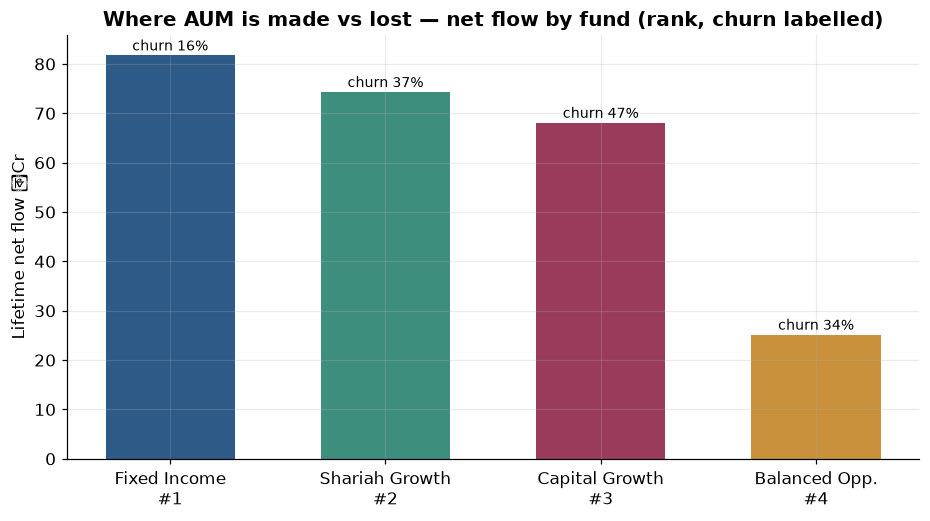

figures: ['01_fund_x_segment.png', '02_aum_made_vs_lost.png']
tables : ['fund_x_rm_counts.csv', 'fund_x_segment_counts.csv', 'recommendation_register.csv', 'segment_x_rm_pct.csv']


In [6]:
# one consolidated 'where AUM is made vs lost' chart for the deck
fig,ax=plt.subplots(figsize=(10,5))
order=rank.sort_values('composite_score',ascending=False).index
x=np.arange(len(order)); w=0.6
nf=[sc1.loc[f,'net_flow_value']/1e7 for f in order]
ax.bar(x, nf, w, color=[COL[f] for f in order])
for xi,f in zip(x,order):
    ax.text(xi, nf[list(order).index(f)]+1, f"churn {sc1.loc[f,'churn_strict']*100:.0f}%", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{SHORT[f]}\n#{int(rank.loc[f,"rank"])}' for f in order])
ax.set_ylabel('Lifetime net flow ৳Cr'); ax.set_title('Where AUM is made vs lost — net flow by fund (rank, churn labelled)')
C.savefig(fig,SEC,'02_aum_made_vs_lost'); plt.show()
print('figures:', sorted(p.name for p in (A/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (A/SEC/'tables').glob('*.csv')))

## Synthesis headline
**Apex's growth problem is a retention problem, not an acquisition problem.** Net flow is strongly positive and growing, but it is concentrated in one fund (Fixed Income) while the others leak; the base is overwhelmingly single-fund; and a couple of high-volume RMs acquire faster than they retain. The three highest-leverage moves — all owner-assigned above — are: (1) defend the leakiest fund and fix SIP persistency at the first missed installment, (2) run a second-fund campaign to existing single-fund customers (cheapest AUM available), and (3) re-tie RM incentives to 1-year retention. See `recommendation_register.csv` for the full owner-assigned list.